<a href="https://www.kaggle.com/code/onikfardin/iot-early-compromise?scriptVersionId=318752849" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mkashifn/nbaiot-dataset/7.gafgyt.combo.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/9.gafgyt.combo.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/5.gafgyt.combo.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/1.mirai.udp.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/4.gafgyt.udp.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/6.gafgyt.udp.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/6.gafgyt.junk.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/data_summary.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/5.gafgyt.udp.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/9.gafgyt.junk.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/9.mirai.scan.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/1.benign.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/2.mirai.udpplain.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/3.gafgyt.combo.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/4.gafgyt.combo.csv
/kaggle/input/datasets/mkashi

In [2]:
# Basic libraries
import numpy as np
import pandas as pd
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Anomaly detection
from sklearn.ensemble import IsolationForest

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# Basic libraries
import numpy as np
import pandas as pd
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Anomaly detection
from sklearn.ensemble import IsolationForest

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mkashifn/nbaiot-dataset/7.gafgyt.combo.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/9.gafgyt.combo.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/5.gafgyt.combo.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/1.mirai.udp.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/4.gafgyt.udp.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/6.gafgyt.udp.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/6.gafgyt.junk.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/data_summary.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/5.gafgyt.udp.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/9.gafgyt.junk.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/9.mirai.scan.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/1.benign.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/2.mirai.udpplain.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/3.gafgyt.combo.csv
/kaggle/input/datasets/mkashifn/nbaiot-dataset/4.gafgyt.combo.csv
/kaggle/input/datasets/mkashi

In [5]:
import pandas as pd

# Load normal IoT behavior
benign1 = pd.read_csv("/kaggle/input/datasets/mkashifn/nbaiot-dataset/1.benign.csv")

print(benign1.shape)

benign1.head()

(49548, 115)


,MI_dir_L5_weight,MI_dir_L5_mean,MI_dir_L5_variance,MI_dir_L3_weight,MI_dir_L3_mean,MI_dir_L3_variance,MI_dir_L1_weight,MI_dir_L1_mean,MI_dir_L1_variance,MI_dir_L0.1_weight,...,HpHp_L0.1_radius,HpHp_L0.1_covariance,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_mean,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc
0,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,...,0.000000,0.0,0.0,1.000000,60.000000,0.000000,60.000000,0.000000,0.0,0.0
1,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,...,34.095047,0.0,0.0,5.319895,344.262695,4.710446,344.262695,22.188299,0.0,0.0
2,1.857879,360.458980,35.789338,1.912127,360.275733,35.923972,1.969807,360.091968,35.991542,1.996939,...,100.081513,0.0,0.0,6.318264,347.703087,9.034660,347.703087,81.625077,0.0,0.0
3,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,...,0.000000,0.0,0.0,1.000000,337.000000,0.000000,337.000000,0.000000,0.0,0.0
4,1.680223,172.140917,18487.448750,1.793580,182.560279,18928.175300,1.925828,193.165753,19153.795810,1.992323,...,0.000000,0.0,0.0,1.000000,60.000000,0.000000,60.000000,0.000000,0.0,0.0


In [6]:
attack1 = pd.read_csv("/kaggle/input/datasets/mkashifn/nbaiot-dataset/1.mirai.udp.csv")

print(attack1.shape)

attack1.head()

(237665, 115)


,MI_dir_L5_weight,MI_dir_L5_mean,MI_dir_L5_variance,MI_dir_L3_weight,MI_dir_L3_mean,MI_dir_L3_variance,MI_dir_L1_weight,MI_dir_L1_mean,MI_dir_L1_variance,MI_dir_L0.1_weight,...,HpHp_L0.1_radius,HpHp_L0.1_covariance,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_mean,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc
0,1.000000,60.0,0.000000e+00,1.000000,60.0,0.000000e+00,1.000000,60.0,0.000000e+00,1.000000,...,0.0,0.0,0.0,1.0,60.0,0.0,60.0,0.0,0.0,0.0
1,1.997781,60.0,0.000000e+00,1.998668,60.0,0.000000e+00,1.999556,60.0,4.547474e-13,1.999956,...,0.0,0.0,0.0,1.0,60.0,0.0,60.0,0.0,0.0,0.0
2,2.997774,60.0,1.364242e-12,2.998664,60.0,4.547474e-13,2.999554,60.0,0.000000e+00,2.999955,...,0.0,0.0,0.0,1.0,60.0,0.0,60.0,0.0,0.0,0.0
3,3.997774,60.0,4.547474e-13,3.998664,60.0,9.094947e-13,3.999554,60.0,0.000000e+00,3.999955,...,0.0,0.0,0.0,1.0,60.0,0.0,60.0,0.0,0.0,0.0
4,4.997774,60.0,4.547474e-13,4.998664,60.0,4.547474e-13,4.999554,60.0,4.547474e-13,4.999955,...,0.0,0.0,0.0,1.0,60.0,0.0,60.0,0.0,0.0,0.0


In [7]:
# Label normal traffic
benign1["label"] = 0

# Label attack traffic
attack1["label"] = 1

In [8]:
data = pd.concat([benign1, attack1], axis=0)

print(data.shape)

data.head()

(287213, 116)


,MI_dir_L5_weight,MI_dir_L5_mean,MI_dir_L5_variance,MI_dir_L3_weight,MI_dir_L3_mean,MI_dir_L3_variance,MI_dir_L1_weight,MI_dir_L1_mean,MI_dir_L1_variance,MI_dir_L0.1_weight,...,HpHp_L0.1_covariance,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_mean,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc,label
0,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,...,0.0,0.0,1.000000,60.000000,0.000000,60.000000,0.000000,0.0,0.0,0
1,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,...,0.0,0.0,5.319895,344.262695,4.710446,344.262695,22.188299,0.0,0.0,0
2,1.857879,360.458980,35.789338,1.912127,360.275733,35.923972,1.969807,360.091968,35.991542,1.996939,...,0.0,0.0,6.318264,347.703087,9.034660,347.703087,81.625077,0.0,0.0,0
3,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,...,0.0,0.0,1.000000,337.000000,0.000000,337.000000,0.000000,0.0,0.0,0
4,1.680223,172.140917,18487.448750,1.793580,182.560279,18928.175300,1.925828,193.165753,19153.795810,1.992323,...,0.0,0.0,1.000000,60.000000,0.000000,60.000000,0.000000,0.0,0.0,0


In [9]:
data = data.sample(frac=1).reset_index(drop=True)

In [10]:
X = data.drop("label", axis=1)
y = data["label"]

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
X_train_normal = X_train[y_train == 0]

print("Normal training samples:", X_train_normal.shape)

Normal training samples: (39652, 115)


In [14]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model.fit(X_train_normal)

IsolationForest(contamination=0.05, n_estimators=200, random_state=42)

In [15]:
pred = model.predict(X_test)

In [16]:
import numpy as np

pred = np.where(pred == -1, 1, 0)

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97      9896
           1       0.99      1.00      0.99     47547

    accuracy                           0.99     57443
   macro avg       0.99      0.97      0.98     57443
weighted avg       0.99      0.99      0.99     57443



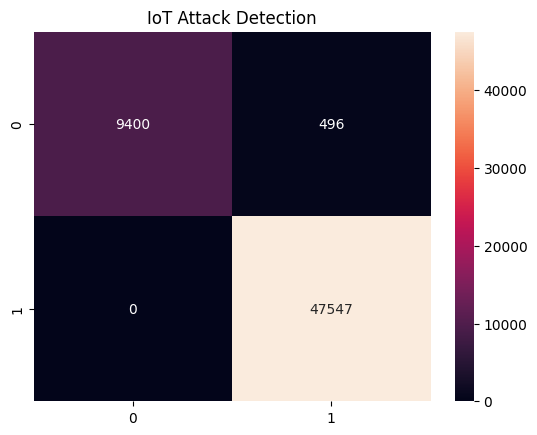

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("IoT Attack Detection")
plt.show()

In [19]:
normal_profile = X_train_normal.mean(axis=0)

In [20]:
void_score = np.abs(X_test - normal_profile).mean(axis=1)

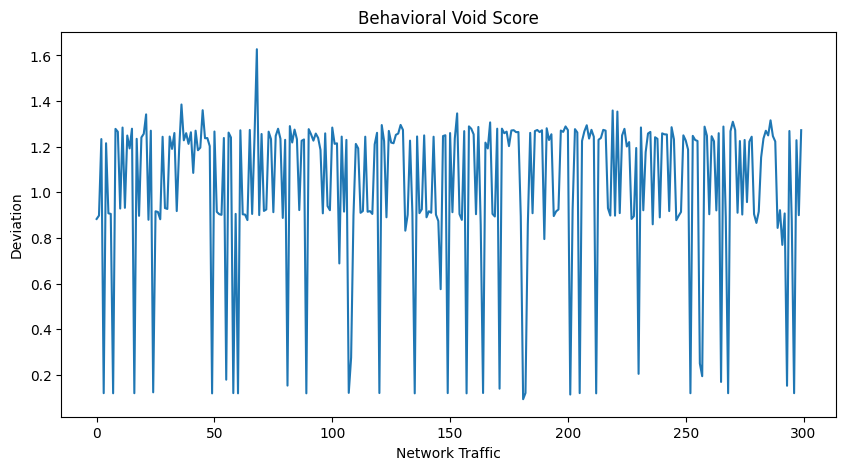

In [21]:
plt.figure(figsize=(10,5))

plt.plot(void_score[:300])

plt.title("Behavioral Void Score")

plt.xlabel("Network Traffic")

plt.ylabel("Deviation")

plt.show()

In [22]:
threshold = np.percentile(void_score, 95)

alerts = void_score > threshold
print(void_score)

print("Early compromise alerts:", alerts.sum())

[0.88289125 0.89792438 1.23317928 ... 1.13784067 1.2255261  1.27709634]
Early compromise alerts: 2873


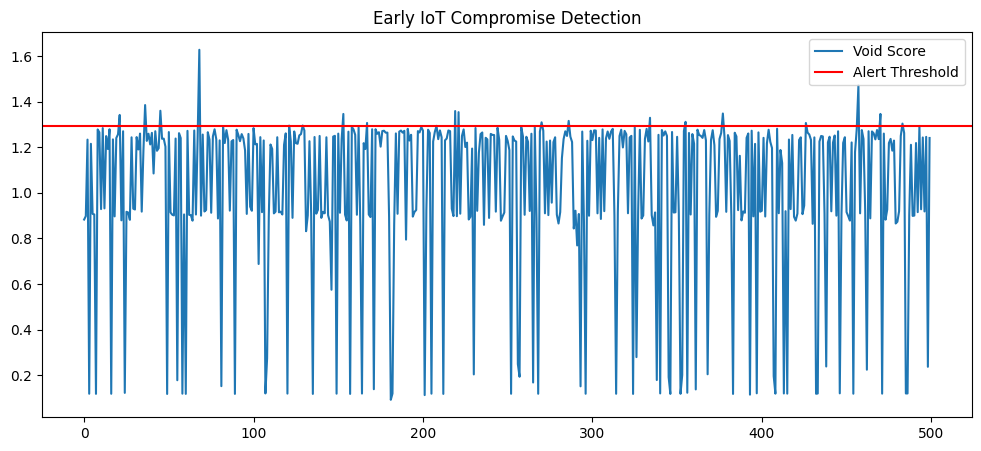

In [23]:
plt.figure(figsize=(12,5))

plt.plot(void_score[:500], label="Void Score")

plt.axhline(threshold, color="red", label="Alert Threshold")

plt.legend()

plt.title("Early IoT Compromise Detection")

plt.show()

In [24]:
import joblib

joblib.dump(model, "iot_behavioral_void_model.pkl")

['iot_behavioral_void_model.pkl']

In [25]:
normal_void = void_score[y_test == 0]
attack_void = void_score[y_test == 1]

print("Normal avg void:", normal_void.mean())
print("Attack avg void:", attack_void.mean())

Normal avg void: 0.1859403056004281
Attack avg void: 1.1335719678205474


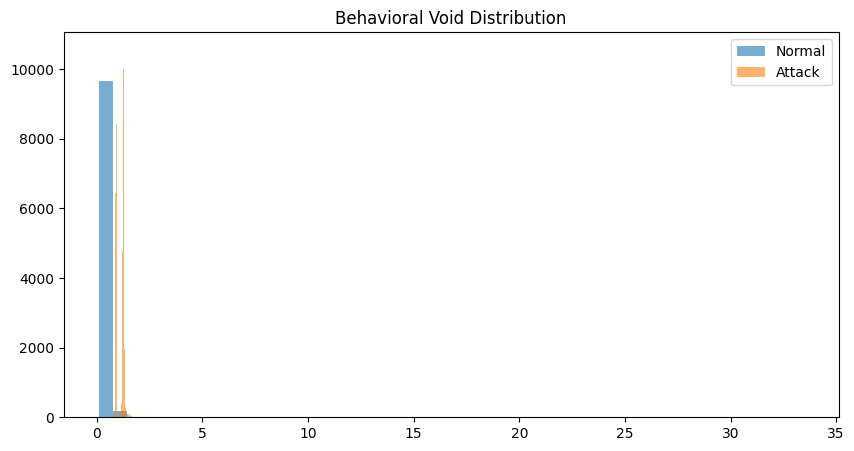

In [26]:
plt.figure(figsize=(10,5))

plt.hist(normal_void, bins=50, alpha=0.6, label="Normal")

plt.hist(attack_void, bins=50, alpha=0.6, label="Attack")

plt.legend()

plt.title("Behavioral Void Distribution")

plt.show()

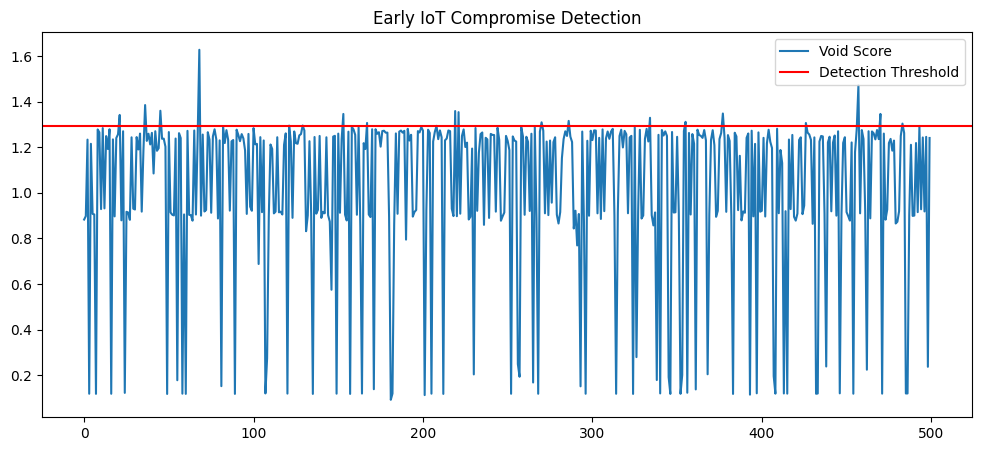

In [27]:
plt.figure(figsize=(12,5))

plt.plot(void_score[:500], label="Void Score")

plt.axhline(threshold, color="red", label="Detection Threshold")

plt.legend()

plt.title("Early IoT Compromise Detection")

plt.show()

In [28]:
# Data handling
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix

In [29]:
base = "/kaggle/input/datasets/mkashifn/nbaiot-dataset/"

In [30]:
benign_files = [
    "1.benign.csv",
    "2.benign.csv",
    "3.benign.csv",
    "4.benign.csv",
    "5.benign.csv"
]

benign_list = []

for file in benign_files:
    df = pd.read_csv(base + file)
    benign_list.append(df)

benign_data = pd.concat(benign_list)

print("Benign Data Shape:", benign_data.shape)

Benign Data Shape: (339155, 115)


In [31]:
attack_files = [
    "1.mirai.udp.csv",
    "1.mirai.scan.csv",
    "1.gafgyt.combo.csv",
    "1.gafgyt.tcp.csv"
]

attack_list = []

for file in attack_files:
    df = pd.read_csv(base + file)
    attack_list.append(df)

attack_data = pd.concat(attack_list)

print("Attack Data Shape:", attack_data.shape)

Attack Data Shape: (497209, 115)


In [32]:
benign_data["label"] = 0
attack_data["label"] = 1

In [33]:
data = pd.concat([benign_data, attack_data])

# Shuffle dataset
data = data.sample(frac=1).reset_index(drop=True)

print("Total Dataset:", data.shape)

Total Dataset: (836364, 116)


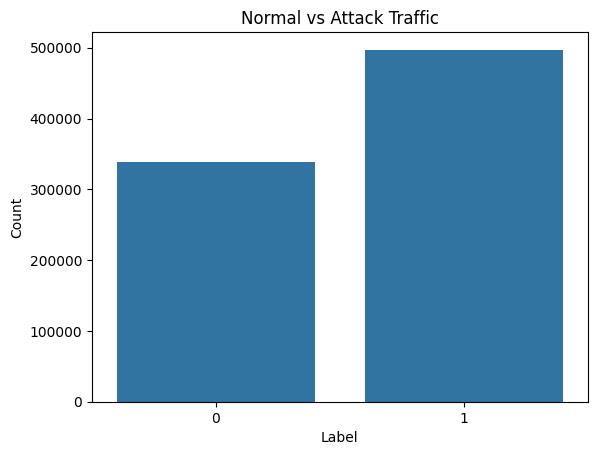

In [34]:
sns.countplot(x=data["label"])

plt.title("Normal vs Attack Traffic")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [35]:
X = data.drop("label", axis=1)
y = data["label"]

In [36]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
X_train_normal = X_train[y_train == 0]

print("Normal training samples:", X_train_normal.shape)

Normal training samples: (271349, 115)


In [39]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model.fit(X_train_normal)

IsolationForest(contamination=0.05, n_estimators=200, random_state=42)

In [40]:
pred = model.predict(X_test)

# Convert prediction format
pred = np.where(pred == -1, 1, 0)

In [41]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.56      0.95      0.70     67806
           1       0.93      0.48      0.64     99467

    accuracy                           0.67    167273
   macro avg       0.74      0.72      0.67    167273
weighted avg       0.78      0.67      0.66    167273



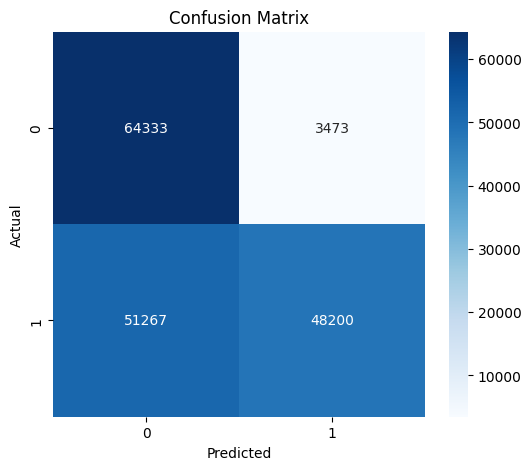

In [42]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [43]:
normal_profile = np.mean(X_train_normal, axis=0)

In [44]:
void_score = np.abs(X_test - normal_profile).mean(axis=1)

print("Average Void Score:", void_score.mean())

Average Void Score: 0.5404338197758088


In [45]:
normal_void = void_score[y_test == 0]
attack_void = void_score[y_test == 1]

print("Normal Avg Void:", normal_void.mean())
print("Attack Avg Void:", attack_void.mean())

Normal Avg Void: 0.31655112205800706
Attack Avg Void: 0.6930531829963068


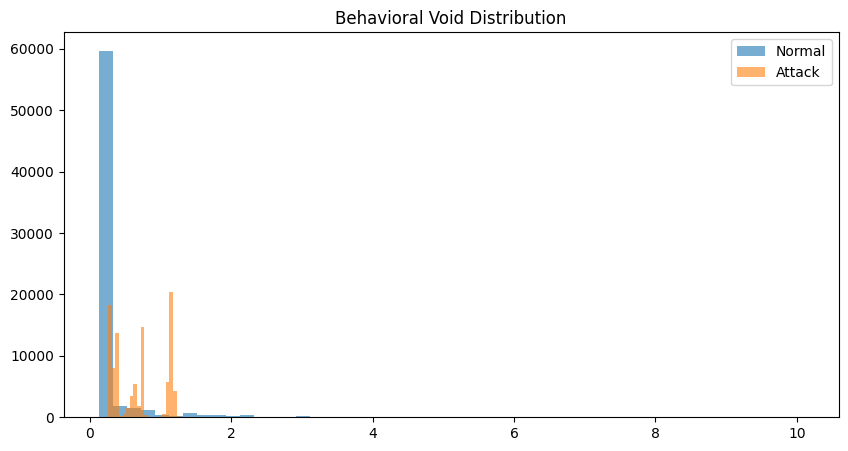

In [46]:
plt.figure(figsize=(10,5))

plt.hist(normal_void, bins=50, alpha=0.6, label="Normal")

plt.hist(attack_void, bins=50, alpha=0.6, label="Attack")

plt.legend()

plt.title("Behavioral Void Distribution")

plt.show()

In [47]:
threshold = np.percentile(void_score, 95)

alerts = void_score > threshold

print("Early compromise alerts:", alerts.sum())

Early compromise alerts: 8364


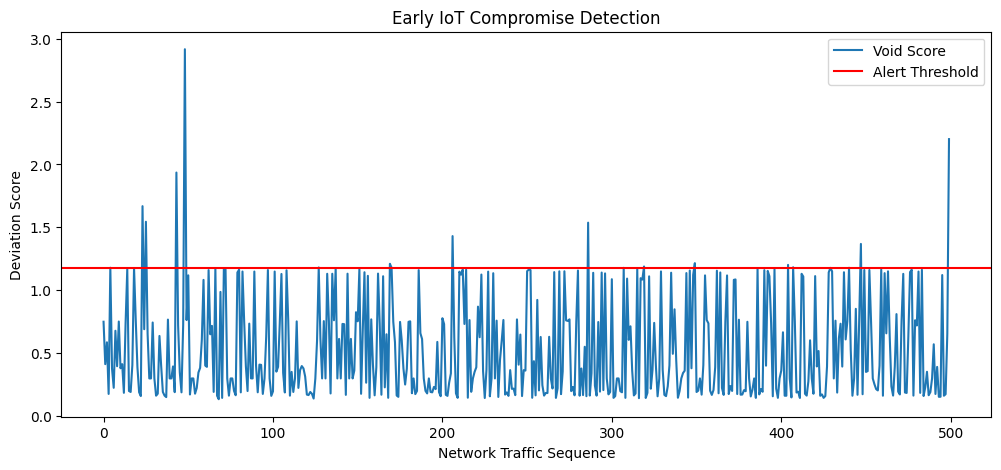

In [48]:
plt.figure(figsize=(12,5))

plt.plot(void_score[:500], label="Void Score")

plt.axhline(threshold, color="red", label="Alert Threshold")

plt.legend()

plt.title("Early IoT Compromise Detection")

plt.xlabel("Network Traffic Sequence")

plt.ylabel("Deviation Score")

plt.show()

In [49]:
import joblib

joblib.dump(model, "behavioral_void_model.pkl")

['behavioral_void_model.pkl']

In [50]:
# STEP 1 — Import libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report

In [51]:
# STEP 2 — Load data
base = "/kaggle/input/datasets/mkashifn/nbaiot-dataset/"

benign_files = [
    "1.benign.csv",
    "2.benign.csv",
    "3.benign.csv",
    "4.benign.csv",
    "5.benign.csv"
]

attack_files = [
    "1.mirai.udp.csv",
    "1.mirai.scan.csv",
    "1.gafgyt.combo.csv",
    "1.gafgyt.tcp.csv"
]

benign = pd.concat([pd.read_csv(base + f) for f in benign_files])
attack = pd.concat([pd.read_csv(base + f) for f in attack_files])

In [52]:
# STEP 3 — Label data
benign["label"] = 0
attack["label"] = 1

data = pd.concat([benign, attack]).sample(frac=1).reset_index(drop=True)

In [53]:
# STEP 4 — Split features and labels
X = data.drop("label", axis=1)
y = data["label"]

In [54]:
# STEP 5 — Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [55]:
# STEP 6 — Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
# STEP 7 — Extract normal training data
X_train_normal = X_train[y_train == 0]

In [57]:
# STEP 8 — Isolation Forest
if_model = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
if_model.fit(X_train_normal)

pred_if = if_model.predict(X_test)
pred_if = np.where(pred_if == -1, 1, 0)

print("Isolation Forest")
print(classification_report(y_test, pred_if))

Isolation Forest
              precision    recall  f1-score   support

           0       0.55      0.95      0.70     67961
           1       0.93      0.48      0.63     99312

    accuracy                           0.67    167273
   macro avg       0.74      0.71      0.67    167273
weighted avg       0.78      0.67      0.66    167273



In [58]:
# STEP 9 — One-Class SVM
ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
ocsvm.fit(X_train_normal)

pred_ocsvm = ocsvm.predict(X_test)
pred_ocsvm = np.where(pred_ocsvm == -1, 1, 0)

print("One-Class SVM")
print(classification_report(y_test, pred_ocsvm))

One-Class SVM
              precision    recall  f1-score   support

           0       0.62      0.95      0.75     67961
           1       0.95      0.60      0.73     99312

    accuracy                           0.74    167273
   macro avg       0.78      0.77      0.74    167273
weighted avg       0.81      0.74      0.74    167273



In [59]:
# STEP 10 — LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, novelty=True)
lof.fit(X_train_normal)

pred_lof = lof.predict(X_test)
pred_lof = np.where(pred_lof == -1, 1, 0)

print("LOF")
print(classification_report(y_test, pred_lof))

LOF
              precision    recall  f1-score   support

           0       0.78      0.95      0.86     67961
           1       0.96      0.82      0.88     99312

    accuracy                           0.87    167273
   macro avg       0.87      0.88      0.87    167273
weighted avg       0.89      0.87      0.87    167273



In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

In [61]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train_normal)

# Distance from cluster centers
distances = kmeans.transform(X_test)
min_dist = np.min(distances, axis=1)

# Threshold
threshold_km = np.percentile(min_dist, 95)

pred_kmeans = (min_dist > threshold_km).astype(int)

print("KMeans")
print(classification_report(y_test, pred_kmeans))

KMeans
              precision    recall  f1-score   support

           0       0.40      0.95      0.57     67961
           1       0.55      0.05      0.09     99312

    accuracy                           0.41    167273
   macro avg       0.48      0.50      0.33    167273
weighted avg       0.49      0.41      0.28    167273



In [62]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20)
pca.fit(X_train_normal)

X_pca = pca.transform(X_test)
X_reconstructed = pca.inverse_transform(X_pca)

# Reconstruction error
mse = np.mean((X_test - X_reconstructed) ** 2, axis=1)

threshold_pca = np.percentile(mse, 95)

pred_pca = (mse > threshold_pca).astype(int)

print("PCA")
print(classification_report(y_test, pred_pca))

PCA
              precision    recall  f1-score   support

           0       0.43      1.00      0.60     67961
           1       0.96      0.08      0.15     99312

    accuracy                           0.45    167273
   macro avg       0.69      0.54      0.37    167273
weighted avg       0.74      0.45      0.33    167273



In [63]:
# Make sure these predictions exist:
# pred_if, pred_ocsvm, pred_lof, pred_kmeans, pred_pca

acc_if = (pred_if == y_test).mean()
acc_ocsvm = (pred_ocsvm == y_test).mean()
acc_lof = (pred_lof == y_test).mean()
acc_kmeans = (pred_kmeans == y_test).mean()
acc_pca = (pred_pca == y_test).mean()

print("=== Accuracy Comparison ===")
print("Isolation Forest:", acc_if)
print("One-Class SVM:", acc_ocsvm)
print("LOF:", acc_lof)
print("KMeans:", acc_kmeans)
print("PCA:", acc_pca)

=== Accuracy Comparison ===
Isolation Forest: 0.6701739073251511
One-Class SVM: 0.7412792261751747
LOF: 0.8712284708231454
KMeans: 0.41175204605644666
PCA: 0.45245197969785916


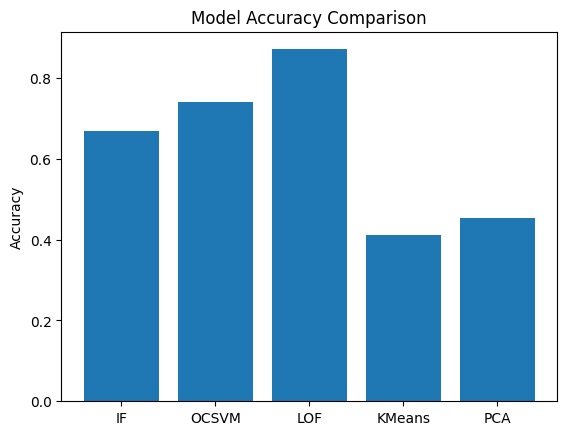

In [64]:
import matplotlib.pyplot as plt

models = ["IF", "OCSVM", "LOF", "KMeans", "PCA"]
accuracies = [acc_if, acc_ocsvm, acc_lof, acc_kmeans, acc_pca]

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [65]:
# MODEL 6 — Elliptic Envelope
from sklearn.covariance import EllipticEnvelope

ee = EllipticEnvelope(contamination=0.05, random_state=42)
ee.fit(X_train_normal[:50000])   # use subset for speed

pred_ee = ee.predict(X_test)
pred_ee = np.where(pred_ee == -1, 1, 0)

print("Elliptic Envelope")
print(classification_report(y_test, pred_ee))
print("Accuracy:", (pred_ee == y_test).mean())

/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-2800.364293571903090 > -2804.779596748590393). You may want to try with a higher value of support_fraction (current value: 0.502).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-2780.386939721250656 > -2781.000454332498975). You may want to try with a higher value of support_fraction (current value: 0.502).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: l

Elliptic Envelope
              precision    recall  f1-score   support

           0       0.39      0.95      0.56     67961
           1       0.00      0.00      0.00     99312

    accuracy                           0.39    167273
   macro avg       0.20      0.48      0.28    167273
weighted avg       0.16      0.39      0.23    167273

Accuracy: 0.38635643528842073


In [66]:
# MODEL 7 — Gaussian Mixture Model (GMM)
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X_train_normal[:50000])  # use subset for speed

log_likelihood = gmm.score_samples(X_test)
threshold_gmm = np.percentile(log_likelihood, 5)

pred_gmm = (log_likelihood < threshold_gmm).astype(int)

print("Gaussian Mixture Model")
print(classification_report(y_test, pred_gmm))
print("Accuracy:", (pred_gmm == y_test).mean())

Gaussian Mixture Model
              precision    recall  f1-score   support

           0       0.43      1.00      0.60     67961
           1       1.00      0.08      0.16     99312

    accuracy                           0.46    167273
   macro avg       0.71      0.54      0.38    167273
weighted avg       0.77      0.46      0.34    167273

Accuracy: 0.45629001691845067


In [67]:
# MODEL 8 — DBSCAN (using nearest-neighbor distance threshold)
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_train_normal[:50000])

distances, _ = nn.kneighbors(X_test)
avg_dist = distances.mean(axis=1)

threshold_db = np.percentile(avg_dist, 95)

pred_dbscan = (avg_dist > threshold_db).astype(int)

print("DBSCAN-inspired Distance Method")
print(classification_report(y_test, pred_dbscan))
print("Accuracy:", (pred_dbscan == y_test).mean())

DBSCAN-inspired Distance Method
              precision    recall  f1-score   support

           0       0.43      0.99      0.60     67961
           1       0.95      0.08      0.15     99312

    accuracy                           0.45    167273
   macro avg       0.69      0.54      0.37    167273
weighted avg       0.74      0.45      0.33    167273

Accuracy: 0.4512682859756207


In [68]:
# MODEL 9 — Random Forest (Supervised Baseline)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, pred_rf))
print("Accuracy:", (pred_rf == y_test).mean())

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67961
           1       1.00      1.00      1.00     99312

    accuracy                           1.00    167273
   macro avg       1.00      1.00      1.00    167273
weighted avg       1.00      1.00      1.00    167273

Accuracy: 0.9999880434977552


In [69]:
# MODEL 10 — XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print("XGBoost")
print(classification_report(y_test, pred_xgb))
print("Accuracy:", (pred_xgb == y_test).mean())

XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67961
           1       1.00      1.00      1.00     99312

    accuracy                           1.00    167273
   macro avg       1.00      1.00      1.00    167273
weighted avg       1.00      1.00      1.00    167273

Accuracy: 0.9999820652466328


In [70]:
# MODEL 6 — AdaBoost
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)

pred_ada = ada.predict(X_test)

print("AdaBoost")
print(classification_report(y_test, pred_ada))
print("Accuracy:", (pred_ada == y_test).mean())

AdaBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67961
           1       1.00      1.00      1.00     99312

    accuracy                           1.00    167273
   macro avg       1.00      1.00      1.00    167273
weighted avg       1.00      1.00      1.00    167273

Accuracy: 0.9999880434977552


In [71]:
# MODEL 7 — Gaussian Mixture Model (GMM)
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X_train_normal[:50000])  # use subset for speed

log_likelihood = gmm.score_samples(X_test)
threshold_gmm = np.percentile(log_likelihood, 5)

pred_gmm = (log_likelihood < threshold_gmm).astype(int)

print("Gaussian Mixture Model")
print(classification_report(y_test, pred_gmm))
print("Accuracy:", (pred_gmm == y_test).mean())

Gaussian Mixture Model
              precision    recall  f1-score   support

           0       0.43      1.00      0.60     67961
           1       1.00      0.08      0.16     99312

    accuracy                           0.46    167273
   macro avg       0.71      0.54      0.38    167273
weighted avg       0.77      0.46      0.34    167273

Accuracy: 0.45629001691845067


In [72]:
# MODEL 8 — DBSCAN (using nearest-neighbor distance threshold)
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_train_normal[:50000])

distances, _ = nn.kneighbors(X_test)
avg_dist = distances.mean(axis=1)

threshold_db = np.percentile(avg_dist, 95)

pred_dbscan = (avg_dist > threshold_db).astype(int)

print("DBSCAN-inspired Distance Method")
print(classification_report(y_test, pred_dbscan))
print("Accuracy:", (pred_dbscan == y_test).mean())

DBSCAN-inspired Distance Method
              precision    recall  f1-score   support

           0       0.43      0.99      0.60     67961
           1       0.95      0.08      0.15     99312

    accuracy                           0.45    167273
   macro avg       0.69      0.54      0.37    167273
weighted avg       0.74      0.45      0.33    167273

Accuracy: 0.4512682859756207


In [73]:
# MODEL 9 — Random Forest (Supervised Baseline)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, pred_rf))
print("Accuracy:", (pred_rf == y_test).mean())

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67961
           1       1.00      1.00      1.00     99312

    accuracy                           1.00    167273
   macro avg       1.00      1.00      1.00    167273
weighted avg       1.00      1.00      1.00    167273

Accuracy: 0.9999880434977552


In [74]:
# MODEL 10 — XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print("XGBoost")
print(classification_report(y_test, pred_xgb))
print("Accuracy:", (pred_xgb == y_test).mean())

XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67961
           1       1.00      1.00      1.00     99312

    accuracy                           1.00    167273
   macro avg       1.00      1.00      1.00    167273
weighted avg       1.00      1.00      1.00    167273

Accuracy: 0.9999820652466328
